# Trading Agent Showdown (Runnable Environment Version)

This notebook trains a lightweight PPO agent on a synthetic trading environment and exports figure/data artifacts.

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


Saved: ../data/processed/ppo_synthetic_equity_curve.csv
Saved: ../figures/ppo_synthetic_equity_curve.png


,step,equity
1194,1194,11.013836
1195,1195,11.057016
1196,1196,11.119032
1197,1197,11.166795
1198,1198,11.172082


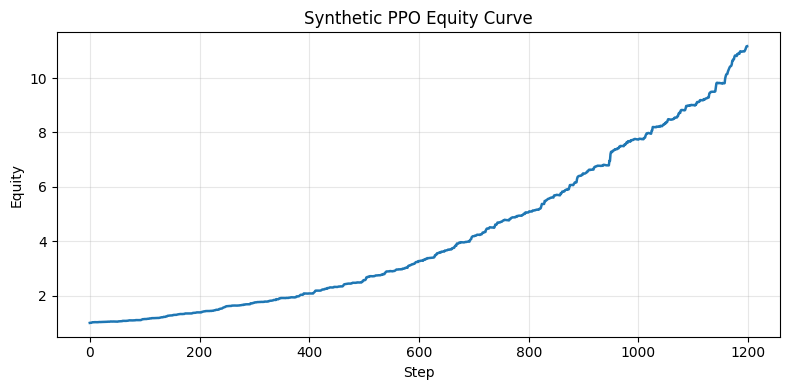

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO

class SyntheticTradingEnv(gym.Env):
    def __init__(self, returns):
        super().__init__()
        self.returns = returns
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(1,), dtype=np.float32)
        self.observation_space = spaces.Box(low=-10.0, high=10.0, shape=(2,), dtype=np.float32)
        self.reset()

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.step_idx = 1
        self.equity = 1.0
        return np.array([self.returns[0], self.returns[1]], dtype=np.float32), {}

    def step(self, action):
        pos = float(np.clip(action[0], -1.0, 1.0))
        r = self.returns[self.step_idx]
        reward = pos * r
        self.equity *= (1.0 + reward)
        self.step_idx += 1
        done = self.step_idx >= len(self.returns)-1
        obs = np.array([self.returns[self.step_idx-1], self.returns[self.step_idx]], dtype=np.float32)
        info = {'equity': self.equity}
        return obs, reward, done, False, info

rng = np.random.default_rng(42)
returns = rng.normal(loc=0.0003, scale=0.01, size=1200).astype(np.float32)
env = SyntheticTradingEnv(returns)
model = PPO('MlpPolicy', env, verbose=0, seed=42, n_steps=128, batch_size=64)
model.learn(total_timesteps=3000)

obs, _ = env.reset()
equity_curve = [1.0]
for _ in range(len(returns)-2):
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, done, trunc, info = env.step(action)
    equity_curve.append(info['equity'])
    if done or trunc:
        break

df = pd.DataFrame({'step': np.arange(len(equity_curve)), 'equity': equity_curve})
proc = Path('../data/processed')
proc.mkdir(parents=True, exist_ok=True)
csv_path = proc / 'ppo_synthetic_equity_curve.csv'
df.to_csv(csv_path, index=False)

fig_dir = Path('../figures')
fig_dir.mkdir(parents=True, exist_ok=True)
fig, ax = plt.subplots(figsize=(8,4))
ax.plot(df['step'], df['equity'], color='tab:blue', lw=1.8)
ax.set_title('Synthetic PPO Equity Curve')
ax.set_xlabel('Step')
ax.set_ylabel('Equity')
ax.grid(alpha=0.3)
fig.tight_layout()
fig_path = fig_dir / 'ppo_synthetic_equity_curve.png'
fig.savefig(fig_path, dpi=200)
print('Saved:', csv_path)
print('Saved:', fig_path)
df.tail()
